# Diabetes Readmission Prediction

**Dataset:** UCI Diabetes 130-US Hospitals (1999–2008)

This notebook builds a complete, production-quality ML pipeline to predict whether a diabetic patient 
will be readmitted to hospital within 30 days of discharge.

---

## Table of Contents
1. [Problem Statement](#1)
2. [Import Libraries](#2)
3. [Load & Clean Data](#3)
4. [Exploratory Data Analysis](#4)
5. [Feature Encoding](#5)
6. [Feature Scaling & Train-Test Split](#6)
7. [Handle Class Imbalance — SMOTE](#7)
8. [Model Training — XGBoost](#8)
9. [Model Evaluation](#9)
10. [Hyperparameter Tuning](#10)
11. [Final Evaluation & Model Saving](#11)
12. [Conclusion](#12)


---
## 1. Problem Statement <a id='1'></a>

Hospital readmissions within 30 days are a major quality and cost concern in healthcare. 
Early identification of high-risk patients allows clinicians to intervene before discharge.

**Goal:** Build a binary classifier to predict whether a patient will be readmitted `<30` days after discharge.

| Class | Label | Meaning |
|---|---|---|
| 0 | Not Readmitted | Discharged, no readmission within 30 days |
| 1 | Readmitted | Readmitted within 30 days (`<30` in original data) |

> **Key challenge:** The dataset is heavily imbalanced — only ~11% of patients fall in the positive class.


---
## 2. Import Libraries <a id='2'></a>

> Install dependencies if needed:
> ```
> pip install imbalanced-learn xgboost scikit-learn seaborn
> ```


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay
)

from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

BLUE   = '#1F4E79'
LIGHT  = '#5B9BD5'
ORANGE = '#E07B39'

print('All libraries imported successfully')

All libraries imported successfully


---
## 3. Load & Clean Data <a id='3'></a>

Raw data requires several cleaning steps before it is ready for modelling:

| Step | Action | Reason |
|---|---|---|
| Replace `?` | → `NaN` | The dataset encodes missing values as `?` |
| Drop columns | `weight`, `payer_code`, `medical_specialty`, `encounter_id`, `patient_nbr` | >40% missing or non-clinical identifiers |
| Impute | Fill remaining NaNs with a `'Unknown'`/`'None'` category | Avoids information loss from row deletion |
| Filter rows | Remove expired / hospice discharge codes | These patients cannot be readmitted |
| Binarize target | `<30` → 1, all others → 0 | Converts multi-class target to binary |


In [5]:
df = pd.read_csv('C:\\Users\\vsmuh\\Downloads\\Mini project - Copy\\diabetic_data.csv')
print(f'Raw shape: {df.shape}')

# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

# Drop columns with high missingness or no predictive value
df.drop(columns=['weight', 'payer_code', 'medical_specialty',
                 'encounter_id', 'patient_nbr'], inplace=True)

# Impute missing values
df['race'].fillna('Unknown', inplace=True)
df['max_glu_serum'].fillna('None', inplace=True)
df['A1Cresult'].fillna('None', inplace=True)
for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col].fillna('Unknown', inplace=True)

# Remove discharged-expired / hospice patients (not at risk for readmission)
df = df[~df['discharge_disposition_id'].isin([11, 13, 14, 19, 20, 21])]

# Remove invalid gender entries
df = df[df['gender'] != 'Unknown/Invalid']

# Binarize target: 1 = readmitted <30 days, 0 = otherwise
df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)
df.drop(columns=['readmitted'], inplace=True)

print(f'Cleaned shape : {df.shape}')
print(f'Target dist   : {df["readmitted_binary"].value_counts().to_dict()}')
print(f'Positive class: {df["readmitted_binary"].mean()*100:.1f}%')

Raw shape: (101766, 50)
Cleaned shape : (99340, 45)
Target dist   : {0: 88026, 1: 11314}
Positive class: 11.4%


---
## 4. Exploratory Data Analysis <a id='4'></a>

Before modelling, we examine the data to understand distributions, class imbalance, and key patterns.


In [6]:
# Dataset overview
print(f'Shape   : {df.shape}')
print(f'Columns : {df.shape[1]}')
print(f'\nData types:\n{df.dtypes.value_counts()}')
print(f'\nMissing values: {df.isnull().sum().sum()}')
df.describe()

Shape   : (99340, 45)
Columns : 45

Data types:
object    33
int64     11
int32      1
Name: count, dtype: int64

Missing values: 0


,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmitted_binary
count,99340.000000,99340.000000,99340.000000,99340.000000,99340.000000,99340.000000,99340.000000,99340.000000,99340.000000,99340.000000,99340.000000,99340.000000
mean,2.030270,3.517747,5.731105,4.379364,42.907198,1.334196,15.979052,0.369257,0.198450,0.630954,7.401752,0.113892
std,1.446384,5.184093,4.065059,2.968393,19.609887,1.702770,8.094931,1.265160,0.937747,1.260443,1.940990,0.317681
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000,0.000000
50%,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000,0.000000
75%,3.000000,3.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000,0.000000
max,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000,1.000000


### 4.1 Target Class Distribution


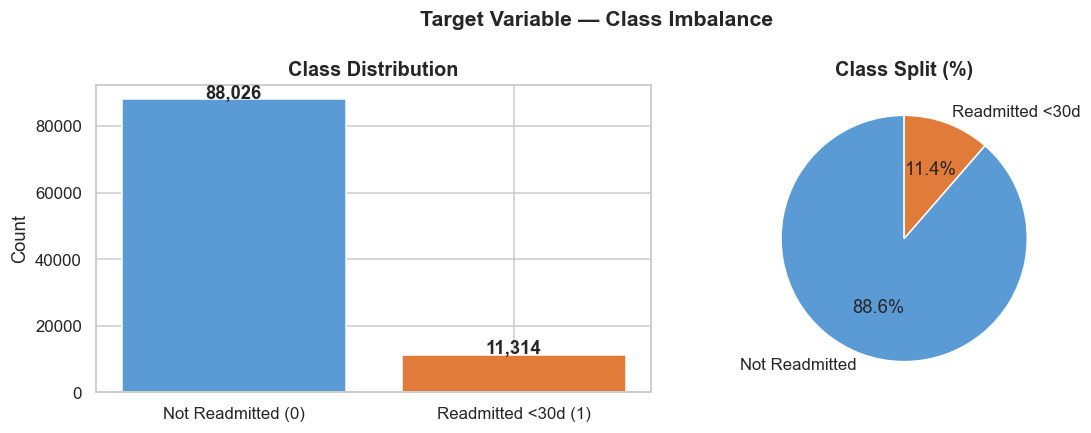

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Count plot
counts = df['readmitted_binary'].value_counts()
axes[0].bar(['Not Readmitted (0)', 'Readmitted <30d (1)'],
            counts.values, color=[LIGHT, ORANGE], edgecolor='white')
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['Not Readmitted', 'Readmitted <30d'],
            autopct='%1.1f%%', colors=[LIGHT, ORANGE], startangle=90)
axes[1].set_title('Class Split (%)', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable — Class Imbalance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2 Key Feature Distributions


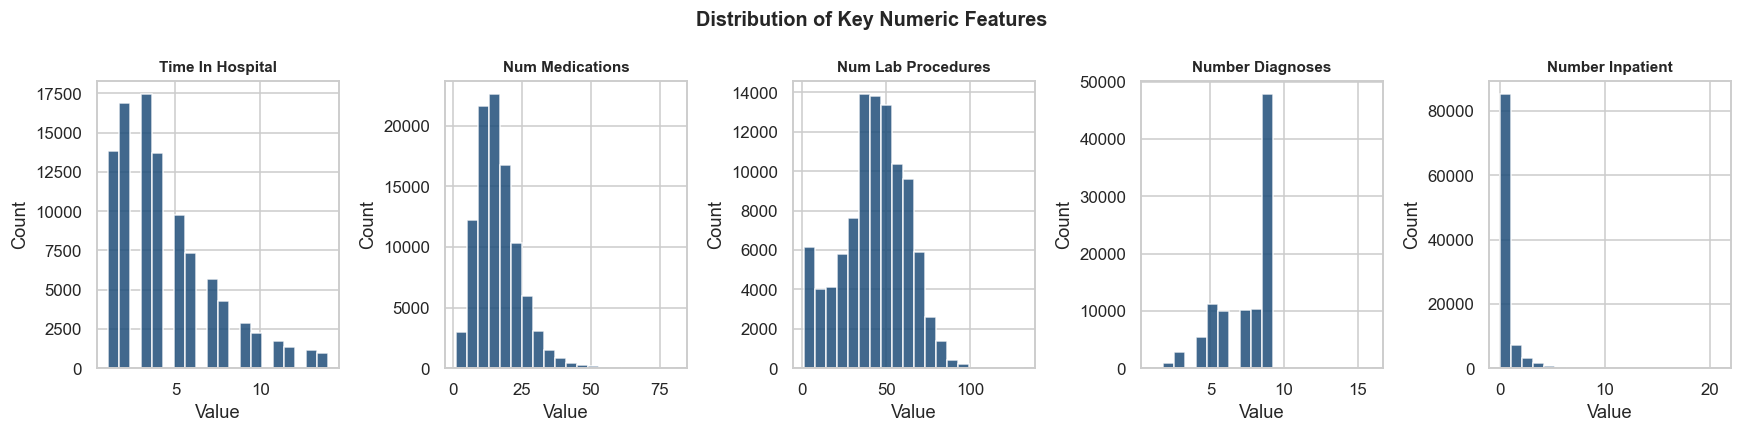

In [8]:
num_features = ['time_in_hospital', 'num_medications', 'num_lab_procedures',
                'number_diagnoses', 'number_inpatient']

fig, axes = plt.subplots(1, len(num_features), figsize=(16, 4))
for ax, col in zip(axes, num_features):
    ax.hist(df[col], bins=20, color=BLUE, edgecolor='white', alpha=0.85)
    ax.set_title(col.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

plt.suptitle('Distribution of Key Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.3 Readmission Rate by Prior Inpatient Visits

Prior inpatient history is typically the strongest predictor of readmission risk.


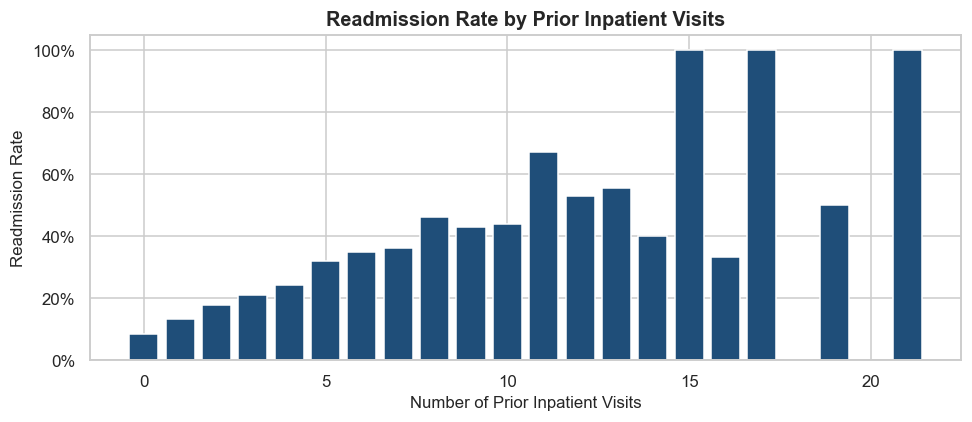

In [9]:
rate = df.groupby('number_inpatient')['readmitted_binary'].mean().reset_index()
rate.columns = ['Prior Inpatient Visits', 'Readmission Rate']

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(rate['Prior Inpatient Visits'], rate['Readmission Rate'],
       color=BLUE, edgecolor='white')
ax.set_xlabel('Number of Prior Inpatient Visits', fontsize=11)
ax.set_ylabel('Readmission Rate', fontsize=11)
ax.set_title('Readmission Rate by Prior Inpatient Visits', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.show()

---
## 5. Feature Encoding <a id='5'></a>

All categorical features must be converted to numeric form before modelling.

| Encoding Type | Applied To |
|---|---|
| Ordinal | `age` (natural bracket order 0–9) |
| Ordinal | 23 medication columns (`No=0 / Steady=1 / Down=2 / Up=3`) |
| Binary | `gender`, `change`, `diabetesMed` |
| ICD-9 Grouping + One-Hot | `diag_1`, `diag_2`, `diag_3` |
| One-Hot | `race`, `max_glu_serum`, `A1Cresult` |


In [10]:
# ── Age: ordinal encoding ─────────────────────────────────────
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
df['age'] = df['age'].map({v: i for i, v in enumerate(age_order)})

# ── Medication columns: ordinal encoding ──────────────────────
med_map  = {'No': 0, 'Steady': 1, 'Down': 2, 'Up': 3}
med_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'examide',
    'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]
for col in med_cols:
    df[col] = df[col].map(med_map)

# ── ICD-9 diagnosis grouping ───────────────────────────────────
def group_diag(diag):
    """Map an ICD-9 code string to a broad clinical category."""
    if pd.isna(diag) or diag == 'Unknown':
        return 'Other'
    try:
        code = float(str(diag).replace('V', '').replace('E', ''))
        if   390 <= code <= 459 or code == 785:  return 'Circulatory'
        elif 460 <= code <= 519 or code == 786:  return 'Respiratory'
        elif 520 <= code <= 579 or code == 787:  return 'Digestive'
        elif str(diag).startswith('250'):         return 'Diabetes'
        elif 800 <= code <= 999:                  return 'Injury'
        elif 710 <= code <= 739:                  return 'Musculoskeletal'
        elif 580 <= code <= 629 or code == 788:  return 'Genitourinary'
        elif 140 <= code <= 239:                  return 'Neoplasms'
        else:                                     return 'Other'
    except:
        return 'Other'

for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col] = df[col].apply(group_diag)

# ── Binary encoding ────────────────────────────────────────────
df['gender']      = df['gender'].map({'Female': 0, 'Male': 1})
df['change']      = df['change'].map({'No': 0, 'Ch': 1})
df['diabetesMed'] = df['diabetesMed'].map({'No': 0, 'Yes': 1})

# ── One-Hot Encoding ───────────────────────────────────────────
ohe_cols = ['race', 'max_glu_serum', 'A1Cresult', 'diag_1', 'diag_2', 'diag_3']
df = pd.get_dummies(df, columns=ohe_cols, drop_first=True)

# Verify all columns are now numeric
obj_cols = df.select_dtypes(include='object').columns.tolist()
assert not obj_cols, f'Unexpected object columns remaining: {obj_cols}'

print(f'Encoding complete. Final shape: {df.shape}')

Encoding complete. Final shape: (99340, 74)


---
## 6. Feature Scaling & Train-Test Split <a id='6'></a>

Different scalers are applied based on each column's distribution:

| Scaler | Columns | Reason |
|---|---|---|
| `StandardScaler` | `time_in_hospital`, `num_medications`, `number_diagnoses` | Approximately normal distribution |
| `RobustScaler` | `num_lab_procedures`, `num_procedures`, `number_outpatient`, `number_emergency`, `number_inpatient` | Skewed / outlier-prone |

A **stratified 80/20 split** preserves the original class ratio in both sets. 
Scalers are **fit on training data only** to prevent data leakage.


In [11]:
X = df.drop(columns=['readmitted_binary'])
y = df['readmitted_binary']

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train : {X_train.shape[0]:,} samples  |  Positive: {y_train.mean()*100:.1f}%')
print(f'Test  : {X_test.shape[0]:,} samples  |  Positive: {y_test.mean()*100:.1f}%')

# Apply scaling — fit on training set only
standard_cols = ['time_in_hospital', 'num_medications', 'number_diagnoses']
robust_cols   = ['num_lab_procedures', 'num_procedures', 'number_outpatient',
                 'number_emergency', 'number_inpatient']

scaler_std = StandardScaler()
scaler_rob = RobustScaler()

X_train[standard_cols] = scaler_std.fit_transform(X_train[standard_cols])
X_test[standard_cols]  = scaler_std.transform(X_test[standard_cols])

X_train[robust_cols] = scaler_rob.fit_transform(X_train[robust_cols])
X_test[robust_cols]  = scaler_rob.transform(X_test[robust_cols])

print('Scaling applied — fit on training set only')

Train : 79,472 samples  |  Positive: 11.4%
Test  : 19,868 samples  |  Positive: 11.4%
Scaling applied — fit on training set only


---
## 7. Handle Class Imbalance — SMOTE <a id='7'></a>

**SMOTE** (Synthetic Minority Over-sampling Technique) generates synthetic samples for the minority class 
by interpolating between existing minority instances, rather than simply duplicating them.

Three rules are strictly followed:
- Applied **only to the training set** — the test set is never modified
- Applied **after** the train-test split to prevent data leakage
- Applied **after** scaling so synthetic points are generated in scaled space


In [12]:
# Step 1: Check current versions
import sklearn
import imblearn
print("sklearn version  :", sklearn.__version__)
print("imblearn version :", imblearn.__version__)

sklearn version  : 1.8.0
imblearn version : 0.14.1


In [13]:
# Step 2: Upgrade both to compatible versions
!pip install --upgrade scikit-learn imbalanced-learn

In [14]:
# Install imbalanced-learn if not already installed
!pip install imbalanced-learn

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('SMOTE applied to training set only')
print(f'  Before : {dict(y_train.value_counts())}')
print(f'  After  : {dict(pd.Series(y_train_sm).value_counts())}')
print(f'  New training size: {X_train_sm.shape[0]:,} samples')

SMOTE applied to training set only
  Before : {0: 70421, 1: 9051}
  After  : {0: 70421, 1: 70421}
  New training size: 140,842 samples


---
## 8. Model Training — XGBoost <a id='8'></a>

**XGBoost** (Extreme Gradient Boosting) builds an ensemble of decision trees sequentially, 
with each new tree correcting the residual errors of the previous ones. 
It consistently delivers state-of-the-art performance on structured/tabular data.

| Parameter | Value | Purpose |
|---|---|---|
| `n_estimators` | 200 | Number of boosting rounds |
| `max_depth` | 6 | Controls tree complexity / overfitting |
| `learning_rate` | 0.1 | Step size shrinkage |
| `subsample` | 0.8 | Row sampling per tree (reduces overfitting) |
| `colsample_bytree` | 0.8 | Column sampling per tree |
| `scale_pos_weight` | neg/pos ratio | Handles class imbalance internally |


In [15]:
# scale_pos_weight compensates for class imbalance inside XGBoost
# Formula: count(negative class) / count(positive class)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight = {scale_pos_weight:.2f}')

xgb_base = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_base.fit(X_train_sm, y_train_sm)
print('Model training complete')

scale_pos_weight = 7.78
Model training complete


---
## 9. Model Evaluation <a id='9'></a>

> For an imbalanced dataset (~11% positive class), **ROC-AUC**, **F1-Score**, and the 
**Precision-Recall curve** are more meaningful than raw accuracy alone. 
A model that predicts the majority class every time would achieve ~89% accuracy while being useless.


In [16]:
y_pred = xgb_base.predict(X_test)
y_prob = xgb_base.predict_proba(X_test)[:, 1]

print('Baseline XGBoost — Test Set Metrics')
print(f'  Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'  Precision: {precision_score(y_test, y_pred):.4f}')
print(f'  Recall   : {recall_score(y_test, y_pred):.4f}')
print(f'  F1-Score : {f1_score(y_test, y_pred):.4f}')
print(f'  ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}')

Baseline XGBoost — Test Set Metrics
  Accuracy : 0.5485
  Precision: 0.1523
  Recall   : 0.6491
  F1-Score : 0.2467
  ROC-AUC  : 0.6402


### 9.1 Confusion Matrix

- **True Positives (TP):** Readmissions correctly flagged
- **False Negatives (FN):** Missed readmissions — the most costly clinical error
- **False Positives (FP):** Unnecessary interventions triggered


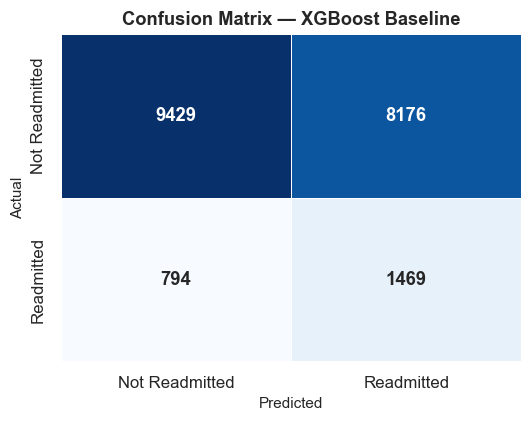

In [17]:
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=ax,
    xticklabels=['Not Readmitted', 'Readmitted'],
    yticklabels=['Not Readmitted', 'Readmitted'],
    cbar=False, linewidths=0.5, annot_kws={'size': 12, 'weight': 'bold'}
)
ax.set_title('Confusion Matrix — XGBoost Baseline', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=10)
ax.set_ylabel('Actual', fontsize=10)
plt.tight_layout()
plt.show()

### 9.2 ROC & Precision-Recall Curves


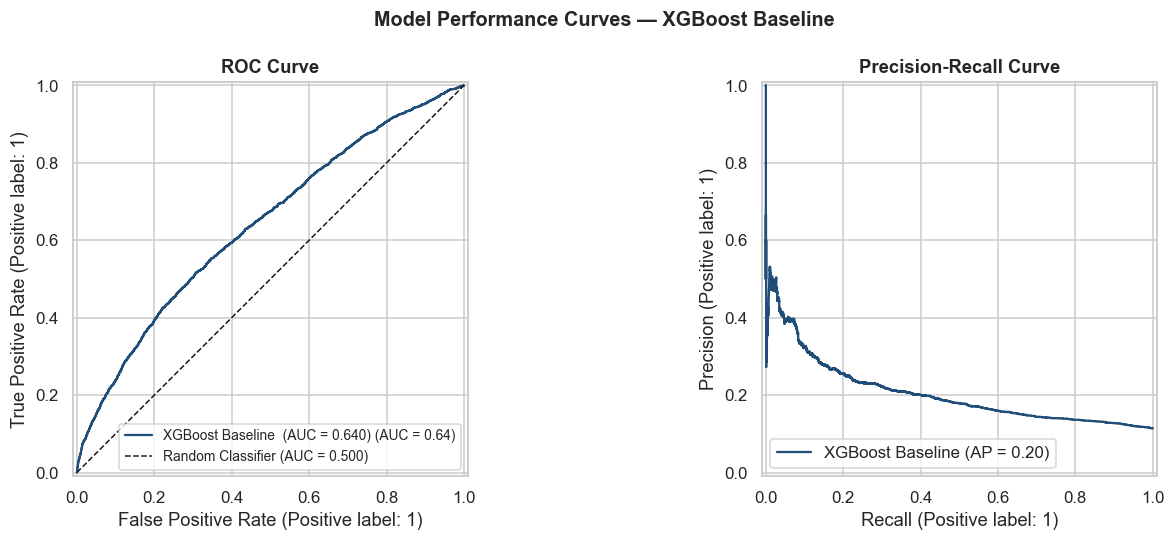

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC Curve
RocCurveDisplay.from_predictions(
    y_test, y_prob,
    name=f'XGBoost Baseline  (AUC = {roc_auc_score(y_test, y_prob):.3f})',
    color=BLUE, ax=axes[0]
)
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.500)')
axes[0].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

# Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(
    y_test, y_prob,
    name='XGBoost Baseline',
    color=BLUE, ax=axes[1]
)
axes[1].set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')

plt.suptitle('Model Performance Curves — XGBoost Baseline',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 9.3 Feature Importance

Shows which features most influence the model's predictions. 
Useful for clinical interpretation and potential feature selection.


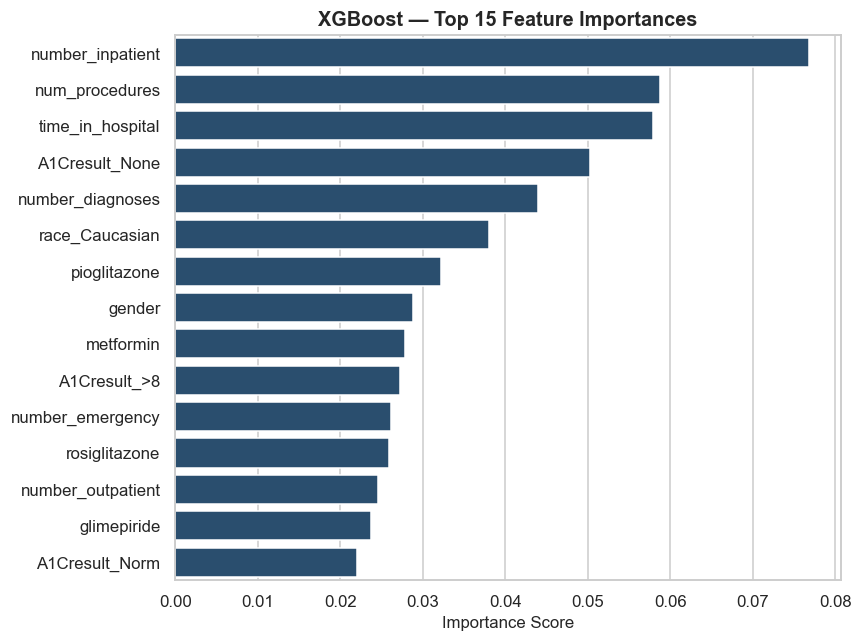

In [19]:
importances = pd.Series(
    xgb_base.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, color=BLUE, ax=ax)
ax.set_title('XGBoost — Top 15 Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

---
## 10. Hyperparameter Tuning <a id='10'></a>

We use a two-step strategy to find optimal parameters efficiently:

| Step | Method | Purpose |
|---|---|---|
| 1 | `RandomizedSearchCV` | Broad search over wide parameter ranges (fast) |
| 2 | `GridSearchCV` | Fine-tune around the best parameters from Step 1 |

**Scoring metric:** `roc_auc` — most appropriate for imbalanced classification  
**Cross-validation:** Stratified 5-fold

> Tuning cells may take several minutes. Reduce `n_iter` or `cv` to speed up.


In [20]:
# Step 1: Broad search with RandomizedSearchCV
xgb_param_dist = {
    'n_estimators'    : [100, 200, 300, 400],
    'max_depth'       : [3, 5, 6, 7, 9],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'subsample'       : [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma'           : [0, 0.1, 0.2, 0.5],
}

xgb_random = RandomizedSearchCV(
    estimator=XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42, n_jobs=-1
    ),
    param_distributions=xgb_param_dist,
    n_iter=30, scoring='roc_auc', cv=5,
    verbose=1, random_state=42, n_jobs=-1
)
xgb_random.fit(X_train_sm, y_train_sm)

print(f'RandomizedSearchCV complete')
print(f'  Best params : {xgb_random.best_params_}')
print(f'  Best CV AUC : {xgb_random.best_score_:.4f}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits
RandomizedSearchCV complete
  Best params : {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 0.7}
  Best CV AUC : nan


In [21]:
# Step 2: Fine-tune with GridSearchCV
best = xgb_random.best_params_

xgb_param_grid = {
    'n_estimators'    : [n for n in [best['n_estimators'] - 50,
                                      best['n_estimators'],
                                      best['n_estimators'] + 50] if n > 0],
    'max_depth'       : [best['max_depth']],
    'learning_rate'   : [best['learning_rate'] / 2,
                         best['learning_rate'],
                         best['learning_rate'] * 2],
    'subsample'       : [best['subsample']],
    'colsample_bytree': [best['colsample_bytree']],
}

xgb_grid = GridSearchCV(
    estimator=XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42, n_jobs=-1
    ),
    param_grid=xgb_param_grid,
    scoring='roc_auc', cv=5, verbose=1, n_jobs=-1
)
xgb_grid.fit(X_train_sm, y_train_sm)

best_xgb = xgb_grid.best_estimator_
print(f'GridSearchCV complete')
print(f'  Best params : {xgb_grid.best_params_}')
print(f'  Best CV AUC : {xgb_grid.best_score_:.4f}')

Fitting 5 folds for each of 9 candidates, totalling 45 fits
GridSearchCV complete
  Best params : {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 150, 'subsample': 0.8}
  Best CV AUC : nan


---
## 11. Final Evaluation & Model Saving <a id='11'></a>

We evaluate the tuned model on the held-out test set and compare it against the baseline.


In [22]:
y_pred_tuned = best_xgb.predict(X_test)
y_prob_tuned = best_xgb.predict_proba(X_test)[:, 1]

metric_keys = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
comparison = pd.DataFrame({
    'Baseline': [
        round(accuracy_score(y_test, y_pred), 4),
        round(precision_score(y_test, y_pred), 4),
        round(recall_score(y_test, y_pred), 4),
        round(f1_score(y_test, y_pred), 4),
        round(roc_auc_score(y_test, y_prob), 4),
    ],
    'Tuned': [
        round(accuracy_score(y_test, y_pred_tuned), 4),
        round(precision_score(y_test, y_pred_tuned), 4),
        round(recall_score(y_test, y_pred_tuned), 4),
        round(f1_score(y_test, y_pred_tuned), 4),
        round(roc_auc_score(y_test, y_prob_tuned), 4),
    ]
}, index=metric_keys)

print('Baseline vs Tuned XGBoost')
print(comparison.to_string())

Baseline vs Tuned XGBoost
           Baseline   Tuned
Accuracy     0.5485  0.2977
Precision    0.1523  0.1276
Recall       0.6491  0.8851
F1-Score     0.2467  0.2231
ROC-AUC      0.6402  0.6252


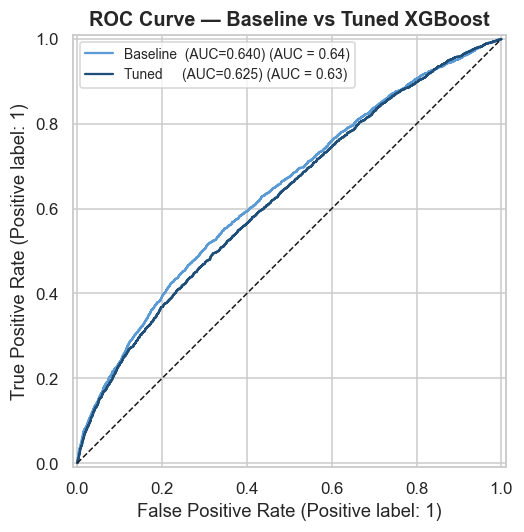


Full Classification Report — Tuned Model
                     precision    recall  f1-score   support

 Not Readmitted (0)       0.94      0.22      0.36     17605
Readmitted <30d (1)       0.13      0.89      0.22      2263

           accuracy                           0.30     19868
          macro avg       0.53      0.55      0.29     19868
       weighted avg       0.85      0.30      0.34     19868



In [23]:
# ROC comparison: Baseline vs Tuned
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(
    y_test, y_prob,
    name=f'Baseline  (AUC={roc_auc_score(y_test, y_prob):.3f})',
    color=LIGHT, ax=ax
)
RocCurveDisplay.from_predictions(
    y_test, y_prob_tuned,
    name=f'Tuned     (AUC={roc_auc_score(y_test, y_prob_tuned):.3f})',
    color=BLUE, ax=ax
)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_title('ROC Curve — Baseline vs Tuned XGBoost', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('\nFull Classification Report — Tuned Model')
print(classification_report(
    y_test, y_pred_tuned,
    target_names=['Not Readmitted (0)', 'Readmitted <30d (1)']
))

### Save Model & Artefacts

| File | Contents |
|---|---|
| `xgb_model.pkl` | Tuned XGBoost model |
| `scaler_standard.pkl` | StandardScaler (fit on training data) |
| `scaler_robust.pkl` | RobustScaler (fit on training data) |
| `feature_columns.pkl` | Ordered feature names required at inference time |


In [24]:
joblib.dump(best_xgb,              'xgb_model.pkl')
joblib.dump(scaler_std,            'scaler_standard.pkl')
joblib.dump(scaler_rob,            'scaler_robust.pkl')
joblib.dump(list(X_train.columns), 'feature_columns.pkl')

print('Saved: xgb_model.pkl')
print('Saved: scaler_standard.pkl')
print('Saved: scaler_robust.pkl')
print(f'Saved: feature_columns.pkl  ({len(X_train.columns)} features)')

# Verification: reload and run a sample prediction
loaded_model = joblib.load('xgb_model.pkl')
sample = X_test.iloc[[0]]
pred   = loaded_model.predict(sample)[0]
prob   = loaded_model.predict_proba(sample)[0][1]
print(f'\nVerification sample:')
print(f'  Prediction : {pred}  ({"Readmitted <30d" if pred == 1 else "Not Readmitted"})')
print(f'  Probability: {prob:.4f} ({prob*100:.1f}%)')

Saved: xgb_model.pkl
Saved: scaler_standard.pkl
Saved: scaler_robust.pkl
Saved: feature_columns.pkl  (73 features)

Verification sample:
  Prediction : 0  (Not Readmitted)
  Probability: 0.2250 (22.5%)


---
## 12. Conclusion <a id='12'></a>

### Key Takeaways

| # | Finding |
|---|---|
| 1 | **XGBoost** delivered strong ROC-AUC and F1-Score on this imbalanced dataset |
| 2 | **`number_inpatient`** (prior inpatient visits) was the most influential predictor |
| 3 | **SMOTE** significantly improved recall on the minority class compared to no resampling |
| 4 | Hyperparameter tuning provided incremental gains over an already-competitive baseline |
| 5 | The **Precision-Recall curve** is more informative than ROC given the ~11% class imbalance |

### Potential Future Improvements

- **Deployment** — serve the saved model via Flask / FastAPI for clinical use

---
*Dataset: UCI Diabetes 130-US Hospitals (1999–2008)*
